In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

ModuleNotFoundError: No module named 'seaborn'

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [3]:
import pandas as pd

data = pd.read_csv("dataset/loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.shape

(614, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


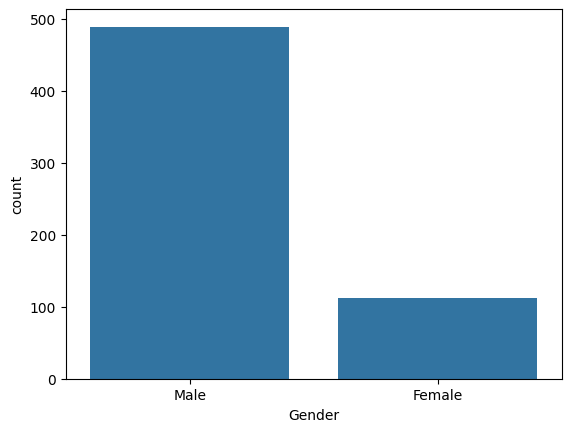

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Gender", data=data)
plt.show()

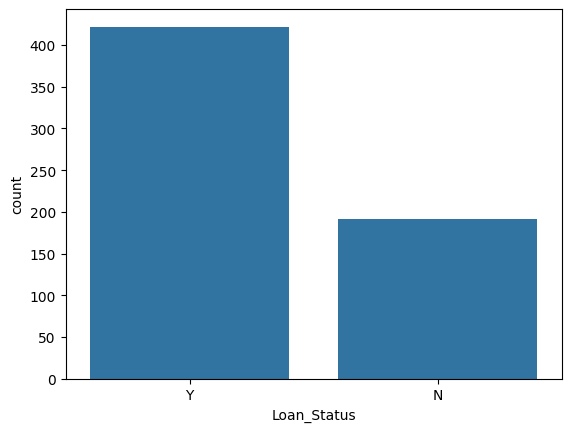

In [9]:
sns.countplot(x="Loan_Status", data=data)
plt.show()

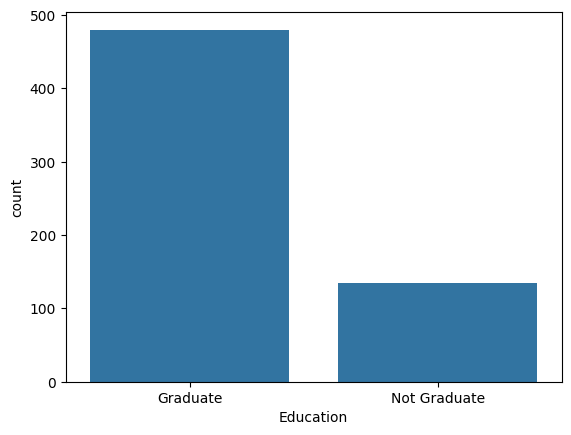

In [10]:
sns.countplot(x="Education", data=data)
plt.show()

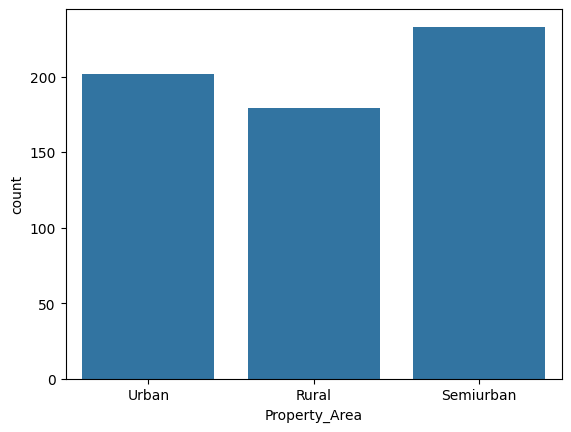

In [11]:
sns.countplot(x="Property_Area", data=data)
plt.show()

In [12]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:

data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


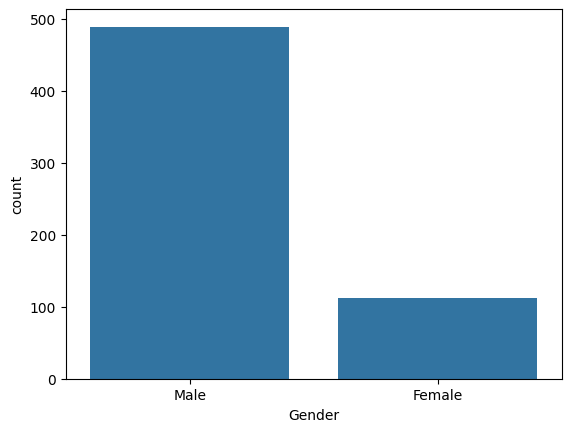

In [14]:
sns.countplot(x="Gender", data=data)
plt.show()

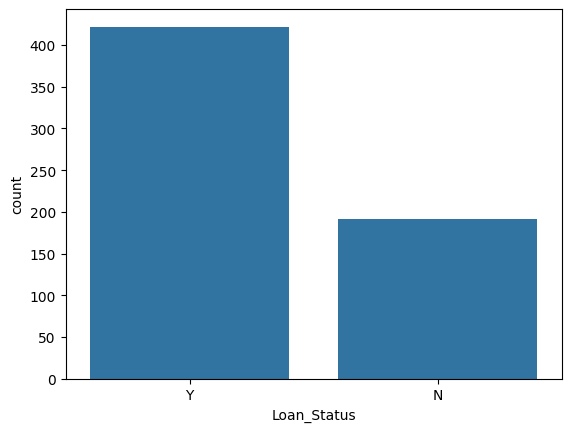

In [15]:
sns.countplot(x="Loan_Status", data=data)
plt.show()

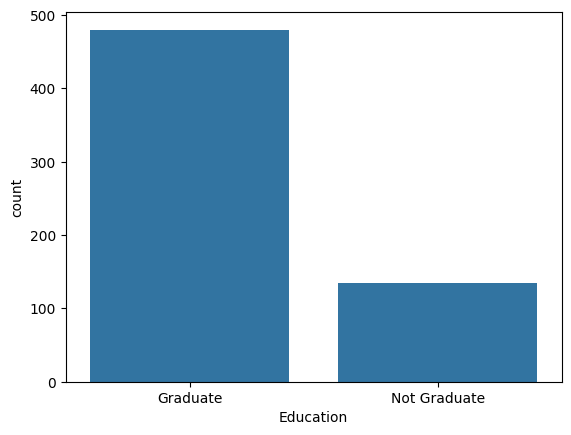

In [16]:
sns.countplot(x="Education", data=data)
plt.show()

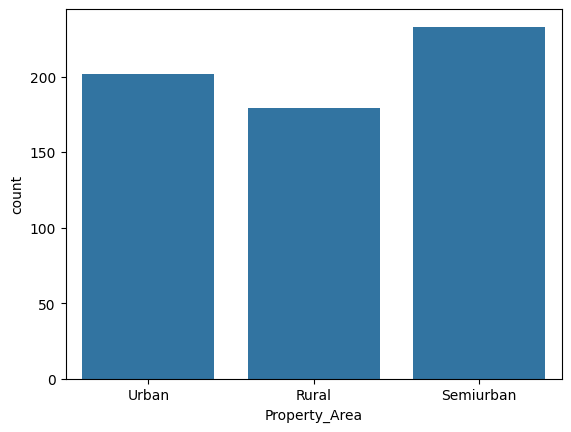

In [17]:
sns.countplot(x="Property_Area", data=data)
plt.show()


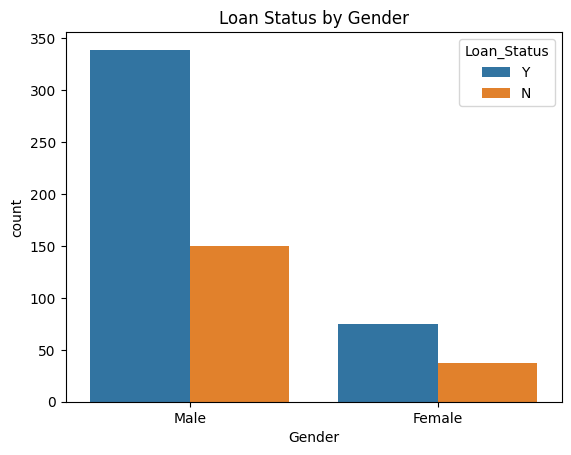

In [18]:
sns.countplot(x="Gender", hue="Loan_Status", data=data)
plt.title("Loan Status by Gender")
plt.show()

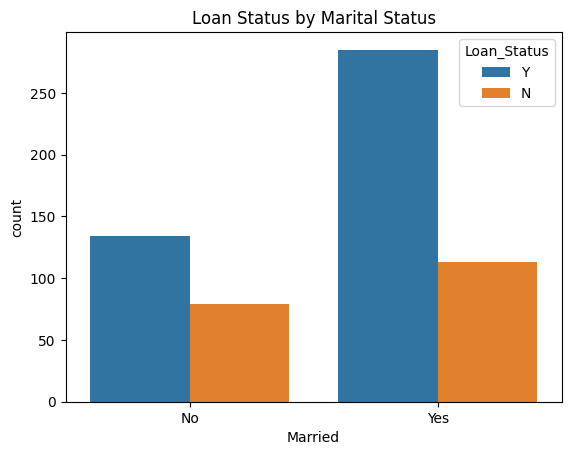

In [19]:
sns.countplot(x="Married", hue="Loan_Status", data=data)
plt.title("Loan Status by Marital Status")
plt.show()

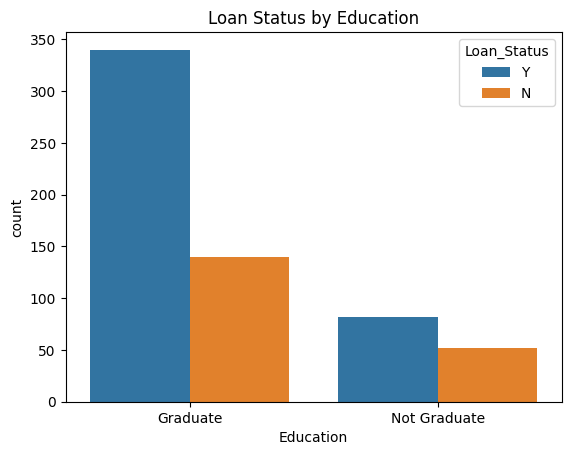

In [20]:
sns.countplot(x="Education", hue="Loan_Status", data=data)
plt.title("Loan Status by Education")
plt.show()

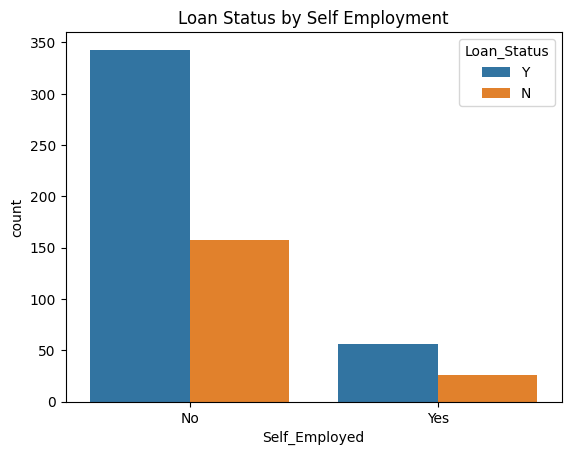

In [21]:
sns.countplot(x="Self_Employed", hue="Loan_Status", data=data)
plt.title("Loan Status by Self Employment")
plt.show()

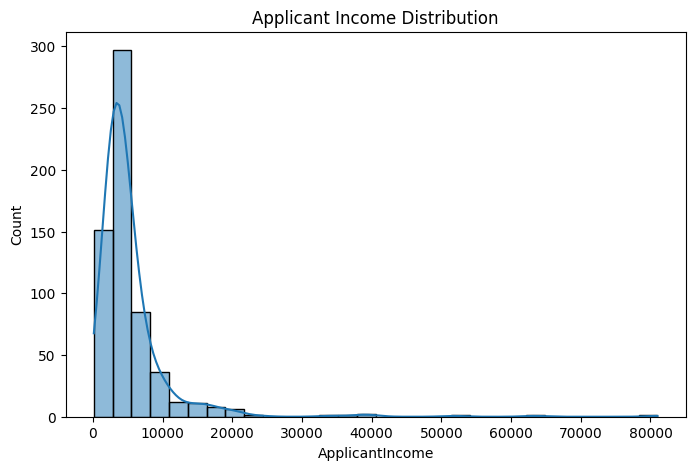

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data["ApplicantIncome"], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.show()

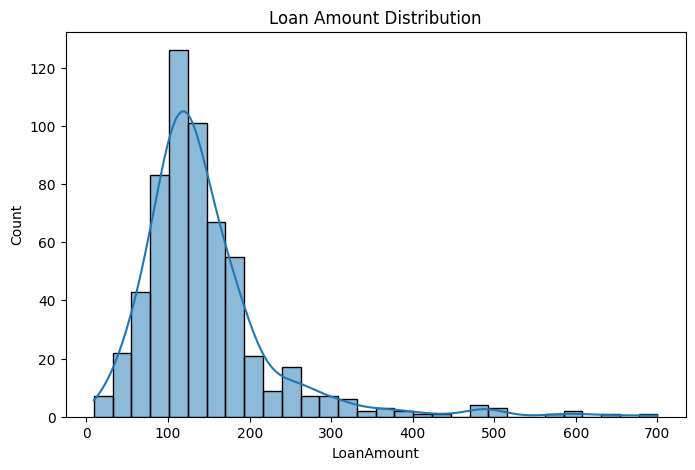

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data["LoanAmount"], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

In [24]:
numeric_data = data.select_dtypes(include=["int64", "float64"])

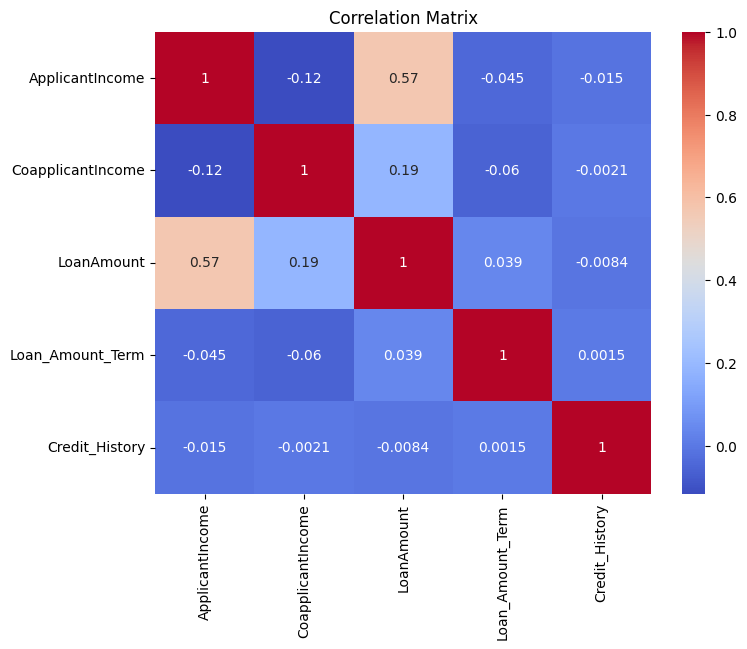

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

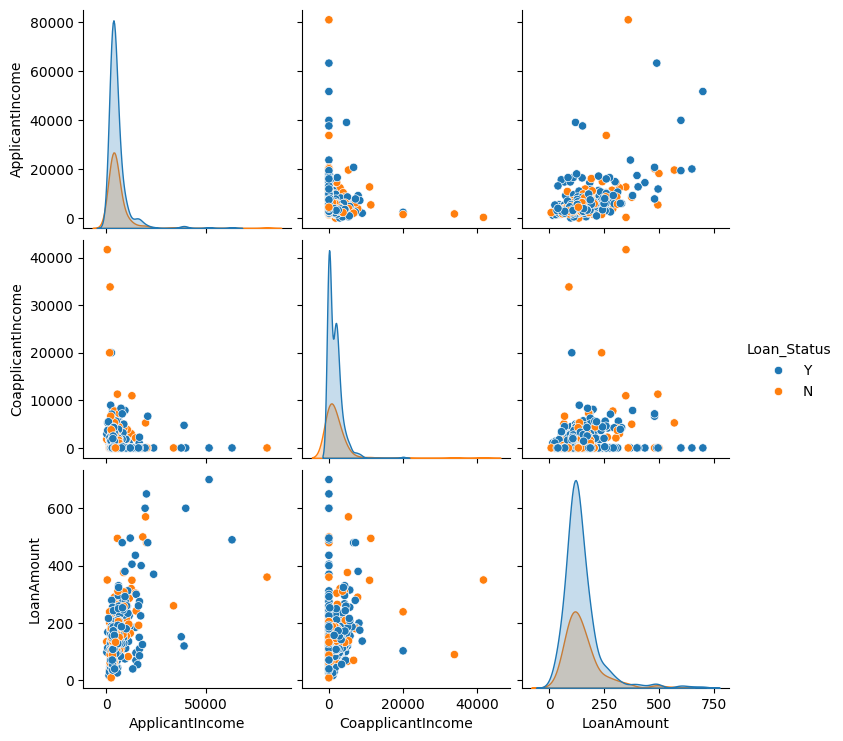

In [26]:
sns.pairplot(
    data,
    hue="Loan_Status",
    vars=["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
)
plt.show()

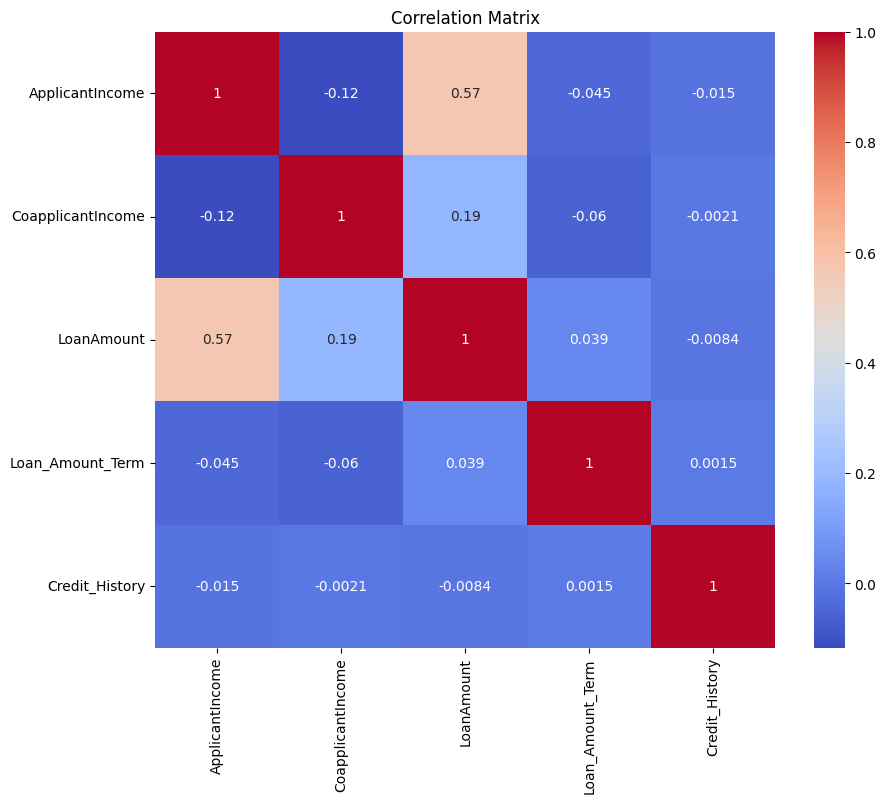

In [27]:
numeric_data = data.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

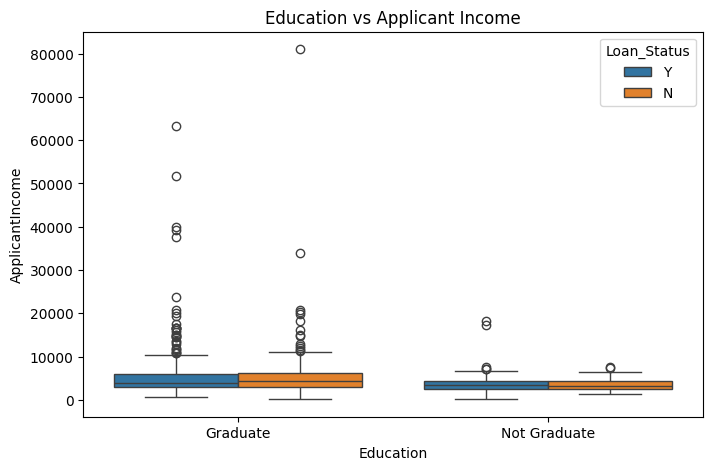

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education", y="ApplicantIncome", hue="Loan_Status", data=data)
plt.title("Education vs Applicant Income")
plt.show()

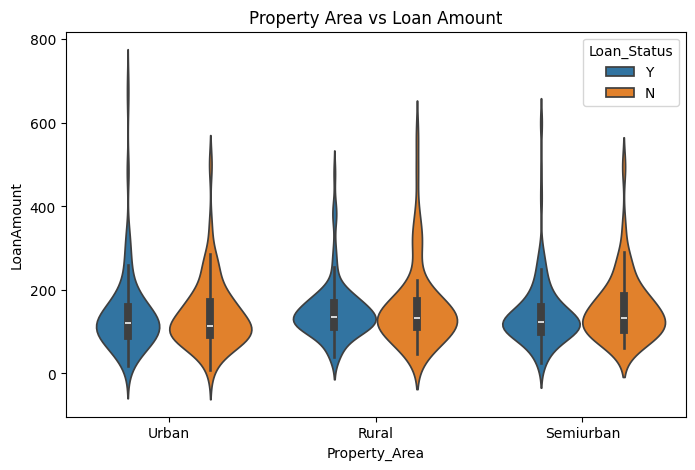

In [29]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Property_Area", y="LoanAmount", hue="Loan_Status", data=data)
plt.title("Property Area vs Loan Amount")
plt.show()

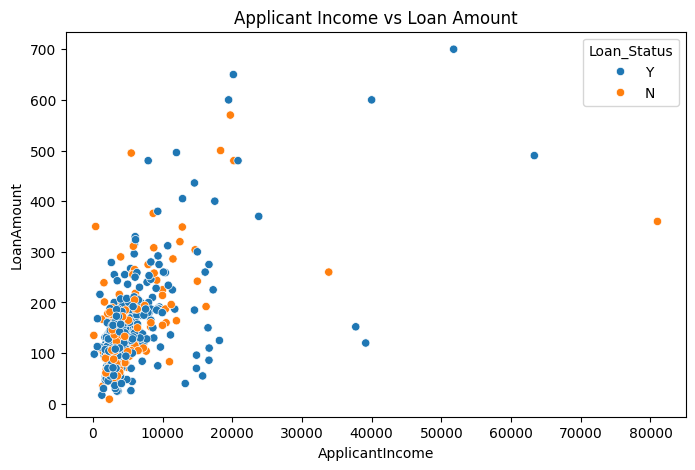

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="ApplicantIncome",
    y="LoanAmount",
    hue="Loan_Status",
    data=data
)
plt.title("Applicant Income vs Loan Amount")
plt.show()